In [9]:
import pandas as pd

# 1. Load raw datasets that we have
# studentInfo contains the final results (Pass, Fail & Withdrawn)
info_df = pd.read_csv('data/studentInfo.csv')

# studentVle contains the daily log events (clicks)
vle_df = pd.read_csv('data/studentVle.csv')

# 2. Aggregate the Activity Logs (studentVle)
# We need to calculate Total Clicks and Active Days per student
engagement_metrics = vle_df.groupby('id_student').agg(
    Total_Activity_Volume=('sum_click', 'sum'),
    Active_Days=('date', 'nunique') # Counts the number of unique days they logged in
).reset_index()

# 3. merge the datasets together
# We join the aggregated engagement data with the student outcomes
final_df = pd.merge(info_df, engagement_metrics, on='id_student', how='left')

# Fill missing values (students who never logged in will have NaN, we convert to 0)
final_df['Total_Activity_Volume'] = final_df['Total_Activity_Volume'].fillna(0)
final_df['Active_Days'] = final_df['Active_Days'].fillna(0)

# 4. Display the first 5 rows of our clean, analytical dataset
print(final_df[['id_student', 'final_result', 'Total_Activity_Volume', 'Active_Days']].head())

   id_student final_result  Total_Activity_Volume  Active_Days
0       11391         Pass                  934.0         40.0
1       28400         Pass                 1435.0         80.0
2       30268    Withdrawn                  281.0         12.0
3       31604         Pass                 2158.0        123.0
4       32885         Pass                 1034.0         70.0


In [4]:
# 1. Calculate Course Completion Rate
# Count how many students Passed or got Distinction
successful_students = final_df[final_df['final_result'].isin(['Pass', 'Distinction'])].shape[0]
total_students = final_df.shape[0]

completion_rate = (successful_students / total_students) * 100
print(f"Overall Completion Rate: {completion_rate:.2f}%")

# 2. Calculating Average Engagement Metrics
average_clicks = final_df['Total_Activity_Volume'].mean()
median_clicks = final_df['Total_Activity_Volume'].median()

average_days = final_df['Active_Days'].mean()
median_days = final_df['Active_Days'].median()

print(f"\n--- Engagement Averages ---")
print(f"Average Total Clicks per Student: {average_clicks:.0f} (Median: {median_clicks:.0f})")
print(f"Average Active Days per Student: {average_days:.1f} (Median: {median_days:.1f})")

Overall Completion Rate: 47.20%

--- Engagement Averages ---
Average Total Clicks per Student: 1479 (Median: 758)
Average Active Days per Student: 63.5 (Median: 48.0)


In [5]:
import scipy.stats as stats

# 1. Create a binary target variable: 1 for Pass/Distinction, 0 for Fail/Withdrawn
final_df['is_successful'] = final_df['final_result'].isin(['Pass', 'Distinction']).astype(int)

# 2. Calculating Pearson correlation between Activity Volume and Success
corr_volume, p_val_volume = stats.pearsonr(final_df['Total_Activity_Volume'], final_df['is_successful'])

# 3. Calculating Pearson correlation between Active Days and Success
corr_days, p_val_days = stats.pearsonr(final_df['Active_Days'], final_df['is_successful'])

print("--- Inferential Statistics: Correlation ---")
print(f"Correlation (Total Clicks & Success): {corr_volume:.3f}")
print(f"Correlation (Active Days & Success):  {corr_days:.3f}")

# A p-value less than 0.05 means the result is statistically significant (not just random chance)
print("\n(Note: A positive correlation indicates that higher engagement is associated with passing.)")

--- Inferential Statistics: Correlation ---
Correlation (Total Clicks & Success): 0.412
Correlation (Active Days & Success):  0.556

(Note: A positive correlation indicates that higher engagement is associated with passing.)


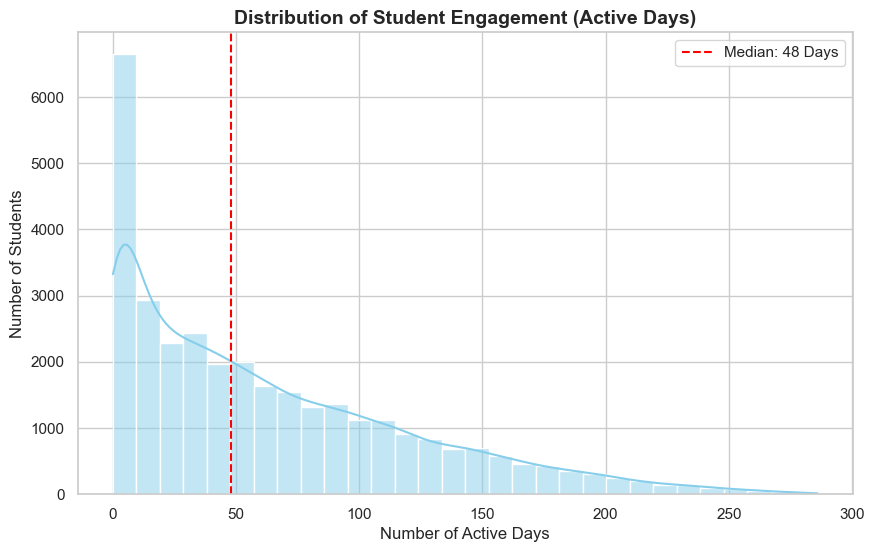

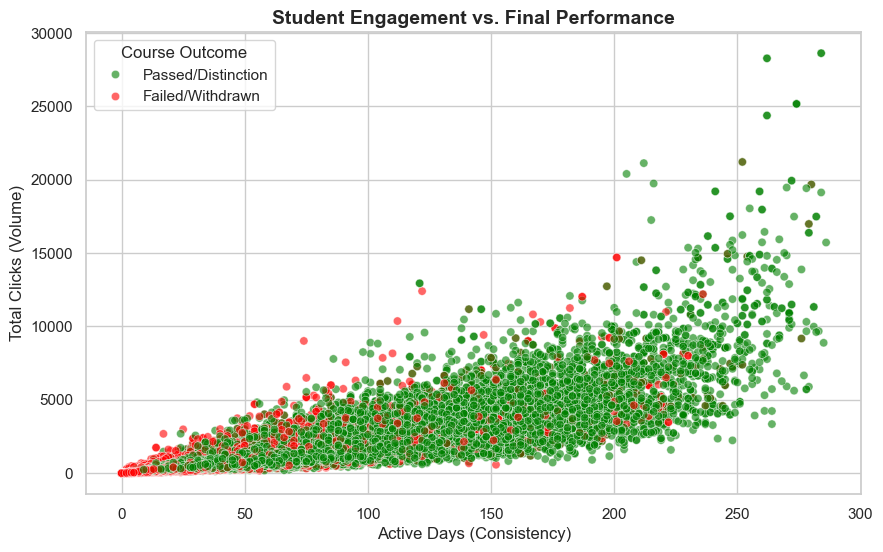

C:\Users\Catona.DESKTOP-VKRMBR2\AppData\Local\Temp\ipykernel_5516\1745862822.py:50: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  bars = sns.barplot(x=percentages, y=stages, palette='Blues_r')


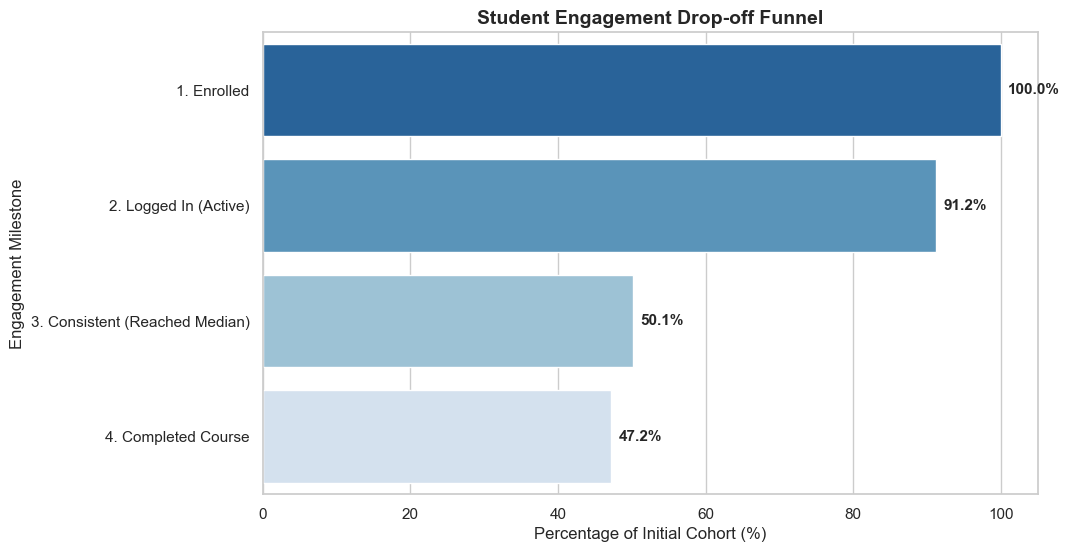

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

# Getting the visual style for charts
sns.set_theme(style="whitegrid")

# ---------------------------------------------------------
# 1. Engagement Distribution Chart (Histogram)
# ---------------------------------------------------------
plt.figure(figsize=(10, 6))
sns.histplot(data=final_df, x='Active_Days', bins=30, kde=True, color='skyblue')
plt.title('Distribution of Student Engagement (Active Days)', fontsize=14, fontweight='bold')
plt.xlabel('Number of Active Days', fontsize=12)
plt.ylabel('Number of Students', fontsize=12)
plt.axvline(final_df['Active_Days'].median(), color='red', linestyle='--', label=f"Median: {final_df['Active_Days'].median():.0f} Days")
plt.legend()
plt.show()

# ---------------------------------------------------------
# 2. Engagement vs. Performance Scatter Plot
# ---------------------------------------------------------
plt.figure(figsize=(10, 6))
# Map the 0/1 success variable to readable labels for the legend
final_df['Status'] = final_df['is_successful'].map({1: 'Passed/Distinction', 0: 'Failed/Withdrawn'})

sns.scatterplot(data=final_df, x='Active_Days', y='Total_Activity_Volume', 
                hue='Status', palette={'Passed/Distinction': 'green', 'Failed/Withdrawn': 'red'}, 
                alpha=0.6)
plt.title('Student Engagement vs. Final Performance', fontsize=14, fontweight='bold')
plt.xlabel('Active Days (Consistency)', fontsize=12)
plt.ylabel('Total Clicks (Volume)', fontsize=12)
plt.legend(title='Course Outcome')
plt.show()

# ---------------------------------------------------------
# 3. Engagement Funnel Chart
# ---------------------------------------------------------
# Calculate the drop-off stages
total_enrolled = len(final_df)
active_students = len(final_df[final_df['Active_Days'] > 0])
consistent_students = len(final_df[final_df['Active_Days'] >= final_df['Active_Days'].median()])
completed_students = len(final_df[final_df['is_successful'] == 1])

# Data for the funnel
stages = ['1. Enrolled', '2. Logged In (Active)', '3. Consistent (Reached Median)', '4. Completed Course']
counts = [total_enrolled, active_students, consistent_students, completed_students]
percentages = [(count / total_enrolled) * 100 for count in counts]

plt.figure(figsize=(10, 6))
bars = sns.barplot(x=percentages, y=stages, palette='Blues_r')
plt.title('Student Engagement Drop-off Funnel', fontsize=14, fontweight='bold')
plt.xlabel('Percentage of Initial Cohort (%)', fontsize=12)
plt.ylabel('Engagement Milestone', fontsize=12)
plt.xlim(0, 105)

# percentage labels to the bars
for index, value in enumerate(percentages):
    plt.text(value + 1, index, f'{value:.1f}%', va='center', fontsize=11, fontweight='bold')

plt.show()

Model Accuracy: 75.42%
This means our model correctly predicted if a student passed or failed this percentage of the time.


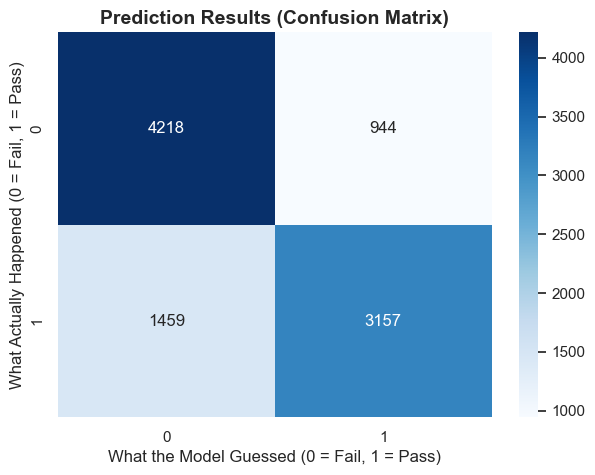

In [7]:
# Step 1: Installing Required Libraries for Logistic Regression)
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Define features (X) and what we want to predict (y)
X = final_df[['Active_Days', 'Total_Activity_Volume']]
y = final_df['is_successful']

# Step 5: Split dataset into training and testing sets
# Used 70% to train the model, and 30% to test it
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Step 6: Train Machine Learning Model
model = LogisticRegression()
model.fit(X_train, y_train)

# Step 7: Evaluate Model using accuracy and confusion matrix
predictions = model.predict(X_test)
accuracy = accuracy_score(y_test, predictions)

print(f"Model Accuracy: {accuracy * 100:.2f}%")
print("This means the model correctly predicted if a student passed or failed this percentage of the time.")

# Step 8: Visualize results
# Drawing a Confusion Matrix to show the exact right and wrong guesses
matrix = confusion_matrix(y_test, predictions)

plt.figure(figsize=(7, 5))
sns.heatmap(matrix, annot=True, fmt='d', cmap='Blues')
plt.title('Prediction Results (Confusion Matrix)', fontsize=14, fontweight='bold')
plt.xlabel('What the Model Guessed (0 = Fail, 1 = Pass)', fontsize=12)
plt.ylabel('What Actually Happened (0 = Fail, 1 = Pass)', fontsize=12)
plt.show()

In [ ]:
import pandas as pd

# 1.Input the brand new data for the two hypothetical students
hypothetical_students = pd.DataFrame({
    'Active_Days': [15, 85],             # Student A has 15 days, Student B has 85 days
    'Total_Activity_Volume': [300, 2500] # Student A has 300 clicks, Student B has 2500 clicks
})

# 2.Asking the model to predict their outcomes
new_predictions = model.predict(hypothetical_students)

# 3.print the results in plain English
print("--- Early Warning System Predictions ---")
for index, prediction in enumerate(new_predictions):
    student_name = f"Student {'A' if index == 0 else 'B'}"
    outcome = "PASS ✅" if prediction == 1 else "FAIL/WITHDRAW ❌"
    
    days = hypothetical_students.iloc[index]['Active_Days']
    clicks = hypothetical_students.iloc[index]['Total_Activity_Volume']
    
    print(f"{student_name} (Days: {days}, Clicks: {clicks}) --> Prediction: {outcome}")